# **Telco Customer Churn Prediction**


**Context:**
* Customer churn is one of the most important business problems in subscription‑based industries such as telecommunications. Retaining an existing customer is significantly cheaper than acquiring a new one, so being able to predict which customers are likely to churn allows companies to take proactive retention actions. 
* The Telco Customer Churn dataset contains customer demographics, service usage patterns, contract types, and billing information. The target variable, Churn, indicates whether a customer left the company. The dataset is moderately imbalanced, with churners representing roughly 26% of all customers.
* This project builds an end‑to‑end machine‑learning pipeline to predict churn, interpret model behavior, and translate insights into actionable business recommendations.


**Project Goals:**
* Understand the characteristics and churn patterns in the dataset.
* Build a clean, leak‑free preprocessing pipeline using scaling + one‑hot encoding.
* Train and compare multiple models (Logistic Regression, Random Forest, XGBoost, LightGBM, SVM).
* Tune the best-performing model using cross‑validated hyperparameter search.
* Evaluate the final model using appropriate metrics for imbalanced classification.
* Use SHAP to interpret feature importance and understand churn drivers.
* Provide business recommendations based on model insights.


**Key Findings:**
- Churn is strongly linked to contract type and monthly charges.

   Customers on month‑to‑month contracts, with high monthly charges, and fiber‑optic internet show the highest churn rates. Customers with long‑term contracts and automatic payments churn significantly less.

- XGBoost performed best overall.

   After hyperparameter tuning, XGBoost achieved:
   - ROC AUC ≈ 0.85 (strong discrimination ability)
   - Stable CV vs test performance → no overfitting
   - Good recall for churners when threshold is adjusted
     
   This makes it a reliable model for real‑world churn prediction.


- Default threshold (0.5) is not optimal.

   At threshold 0.5:
   - Recall for churners = 0.50
   - Precision for churners = 0.68
     
   Lowering the threshold to 0.3–0.25 increases recall to 78–82%, which is often preferred in churn‑reduction programs where missing a churner is costly.


- SHAP reveals clear churn drivers.

   Top features influencing churn include:
   - Contract type (month‑to‑month increases churn risk)
   - Tenure (shorter tenure = higher churn)
   - MonthlyCharges (higher charges = higher churn)
   - OnlineSecurity / TechSupport (lack of these services increases churn)
   - PaymentMethod (electronic check customers churn more)
     
   These insights align with real telecom churn behavior.


**What This Means for the Business:**

High‑risk customer segments:
- New customers (low tenure)
- Month‑to‑month contract users
- Customers paying via electronic check
- Customers with fiber‑optic internet but no security/tech support add‑ons
- Customers with high monthly charges

**Recommended Retention Actions:**

- Offer discounts or loyalty incentives to high‑charge customers
- Encourage contract upgrades (1‑year or 2‑year)
- Bundle OnlineSecurity / TechSupport at a reduced rate
- Target electronic‑check users with payment method incentives
- Provide onboarding support for new customers to reduce early churn

**Key Technical Takeaways:**

- Pipelines prevent data leakage

   All preprocessing (scaling + one‑hot encoding) happens inside the pipeline, ensuring the model never sees test data during training.

- ROC AUC is the right metric

   Accuracy is misleading for imbalanced datasets.
   ROC AUC and recall give a more realistic picture of model performance.

- Threshold tuning is essential

   Churn prediction is a business problem.
   The “best” threshold depends on whether the company prioritizes:
   - catching more churners (higher recall), or
   - avoiding unnecessary retention costs (higher precision)


- SHAP makes the model explainable

   Even complex models like XGBoost become transparent with SHAP, enabling:
   - feature importance
   - direction of impact
   - customer‑level explanations


**Final Summary:**

This project demonstrates a complete churn‑prediction workflow:
- Clean preprocessing
- Multiple model comparison
- Hyperparameter tuning
- Proper evaluation for imbalanced data
- SHAP‑based interpretability
- Actionable business recommendat-ions
  
The tuned XGBoost model provides strong predictive performance and clear insights into customer behavior, making it a practical tool for telecom retention strategies.


In [28]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
pd.set_option('display.max_columns', None)     # Show all columns
pd.set_option('display.expand_frame_repr', False)  # Prevent line wrapping with '...'
import matplotlib.pyplot as plt
import seaborn as sns
import time


from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.metrics import precision_score, recall_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


**Data read and manipulation**
* Removed CustomerID because it duplicates the existing index.
* Converted TotalCharges from string to numeric due to incorrect data type.
* Standardized SeniorCitizen values to “Yes/No” for consistency with other binary fields.
* Identified 11 missing values in TotalCharges and imputed them using the column mean.





In [2]:
df = pd.read_csv('../input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df = df.drop(['customerID'], axis = 1)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df['SeniorCitizen']= df['SeniorCitizen'].map({0: "No", 1: "Yes"})
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.select_dtypes(include='number').describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


In [8]:
for col in df.select_dtypes(include='object').columns:
    print(f"\nColumn: {col}")
    print("Unique values:", df[col].unique())
    print("Count:", df[col].nunique())


Column: gender
Unique values: ['Female' 'Male']
Count: 2

Column: SeniorCitizen
Unique values: ['No' 'Yes']
Count: 2

Column: Partner
Unique values: ['Yes' 'No']
Count: 2

Column: Dependents
Unique values: ['No' 'Yes']
Count: 2

Column: PhoneService
Unique values: ['No' 'Yes']
Count: 2

Column: MultipleLines
Unique values: ['No phone service' 'No' 'Yes']
Count: 3

Column: InternetService
Unique values: ['DSL' 'Fiber optic' 'No']
Count: 3

Column: OnlineSecurity
Unique values: ['No' 'Yes' 'No internet service']
Count: 3

Column: OnlineBackup
Unique values: ['Yes' 'No' 'No internet service']
Count: 3

Column: DeviceProtection
Unique values: ['No' 'Yes' 'No internet service']
Count: 3

Column: TechSupport
Unique values: ['No' 'Yes' 'No internet service']
Count: 3

Column: StreamingTV
Unique values: ['No' 'Yes' 'No internet service']
Count: 3

Column: StreamingMovies
Unique values: ['No' 'Yes' 'No internet service']
Count: 3

Column: Contract
Unique values: ['Month-to-month' 'One year' 'T

In [9]:
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [10]:
df_missing = df[df['TotalCharges'].isnull()]
df_missing

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,No,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,No,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,No,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,No,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,No,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [11]:
mean_total_charges = df['TotalCharges'].mean()
df['TotalCharges'] = df['TotalCharges'].fillna(mean_total_charges)
df['TotalCharges'].isna().sum()

np.int64(0)

In [12]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**Data Visualization**
* Examined overall churn distribution to understand imbalance.
* Explored demographic patterns (gender, senior status, partner, dependents) and how they relate to churn.
* Analyzed service usage (internet type, security add‑ons, tech support, streaming services) with churn splits.
* Calculated churn rates across categories, identifying high‑risk groups such as month‑to‑month contracts, electronic‑check users, and PaperlessBilling customers.
* Investigated numeric features including tenure, MonthlyCharges, and TotalCharges.


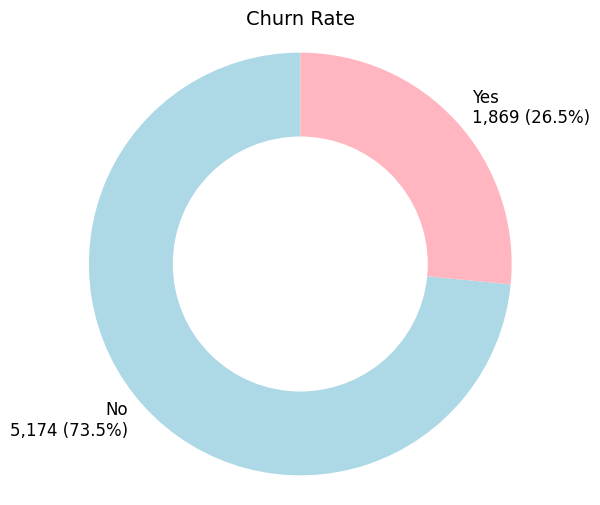

In [13]:
# Churn distribution
counts = (
    df['Churn']
    .dropna()
    .value_counts()
    .reindex(["No", "Yes"])
    .fillna(0)
    .astype(int)
)

percent = counts / counts.sum() * 100

# Labels: count + %
labels = [
    f"{lab}\n{cnt:,} ({pct:.1f}%)"
    for lab, cnt, pct in zip(counts.index, counts.values, percent.values)
]

colors = ["#ADD8E6", "#FFB6C1"]

plt.figure(figsize=(6, 6))

wedges, texts = plt.pie(
    counts.values,
    labels=labels,
    colors=colors,
    startangle=90,
    textprops={"fontsize": 12},
)

centre_circle = plt.Circle((0, 0), 0.60, color="white")
plt.gca().add_artist(centre_circle)

plt.title("Churn Rate", fontsize=14)
plt.axis("equal")  # keeps circle shape
plt.show()

Customer Demograpics

- Gender shows almost no difference in churn rates, indicating it is not a meaningful predictor.
- Senior citizens churn slightly more than younger customers, reflecting higher sensitivity to service cost and contract flexibility.
- Customers without partners have higher churn, suggesting that single‑person households may be more price‑sensitive or less tied to long‑term service commitments.
- Customers without dependents also churn more, reinforcing the pattern that smaller or single‑member households are more likely to switch providers.
  
Overall, demographic factors show weak to moderate influence, especially compared to contract type, tenure, and monthly charges, which emerge as much stronger churn drivers.


/tmp/ipykernel_55/2720328900.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_55/2720328900.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby([churn_col, gender_col])


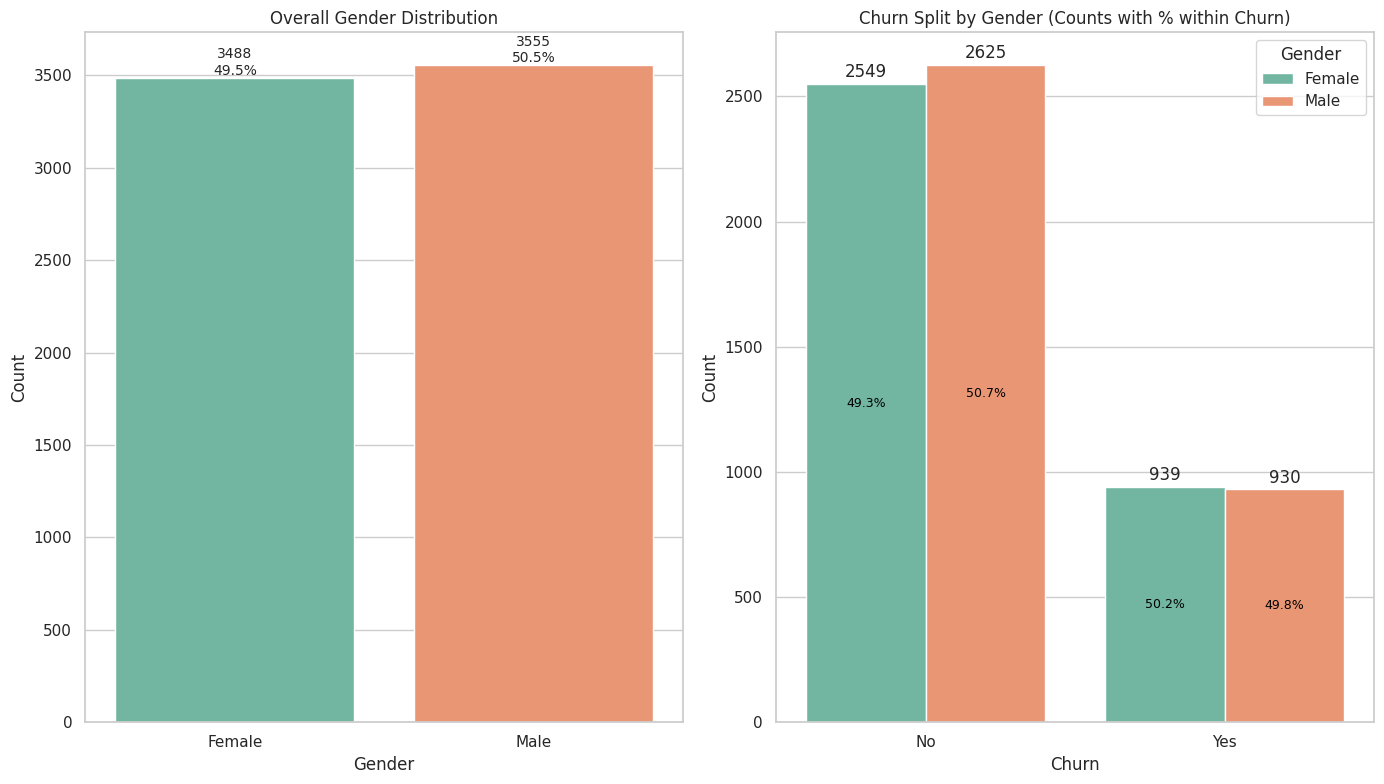

In [14]:
# Churn distribution by gender
gender_col = 'gender'   
churn_col  = 'Churn'    

df[gender_col] = pd.Categorical(df[gender_col], categories=['Female', 'Male'], ordered=True)
df[churn_col]  = pd.Categorical(df[churn_col],  categories=['No', 'Yes'],     ordered=True)

sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# Chart 1: Overall Gender Distribution (counts + % of total)

ax0 = axes[0]

gender_counts = df[gender_col].value_counts().reindex(['Female', 'Male']).fillna(0).astype(int)
gender_pct = (gender_counts / gender_counts.sum() * 100)

sns.barplot(
    x=gender_counts.index,
    y=gender_counts.values,
    palette='Set2',
    ax=ax0
)

ax0.set_title('Overall Gender Distribution')
ax0.set_xlabel('Gender')
ax0.set_ylabel('Count')

# Annotate both count and percent on each bar 
for i, v in enumerate(gender_counts.values):
    ax0.text(
        i, v,
        f'{int(v)}\n{gender_pct.iloc[i]:.1f}%',
        ha='center', va='bottom', fontsize=10
    )

# Chart 2: Churn split by Gender (counts + % within each churn)

ax1 = axes[1]

counts = (
    df.groupby([churn_col, gender_col])
      .size()
      .reset_index(name='count')
)

# Ensure all combinations exist (even if zero)
idx = pd.MultiIndex.from_product(
    [df[churn_col].cat.categories, df[gender_col].cat.categories],
    names=[churn_col, gender_col]
)
counts = counts.set_index([churn_col, gender_col]).reindex(idx, fill_value=0).reset_index()

# Percentages within each churn group
counts['percent_within_churn'] = (
    counts.groupby(churn_col)['count']
          .transform(lambda x: np.where(x.sum() == 0, 0, x / x.sum() * 100))
)

bar = sns.barplot(
    data=counts,
    x=churn_col, y='count', hue=gender_col,
    palette='Set2', ax=ax1
)

ax1.set_title('Churn Split by Gender (Counts with % within Churn)')
ax1.set_xlabel('Churn')
ax1.set_ylabel('Count')
ax1.legend(title='Gender')

# Annotate count on the top edge of each bar
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.0f', label_type='edge', padding=2)

percent_lookup = {
    (row[churn_col], row[gender_col]): row['percent_within_churn']
    for _, row in counts.iterrows()
}

hue_labels = [t.get_text() for t in ax1.legend_.get_texts()]
containers = ax1.containers
xticklabels = [t.get_text() for t in ax1.get_xticklabels()]

# Iterate bars per hue container to map (churn, gender) correctly
for hue_idx, c in enumerate(containers):
    gender_val = hue_labels[hue_idx]
    for rect_idx, rect in enumerate(c):
        height = rect.get_height()
        if height <= 0:
            continue
        churn_val = xticklabels[rect_idx]  # rect order aligns with x categories
        pct = percent_lookup.get((churn_val, gender_val), np.nan)
        ax1.text(
            rect.get_x() + rect.get_width()/2,
            rect.get_y() + height/2,
            f'{pct:.1f}%',
            ha='center', va='center', fontsize=9, color='black'
        )

plt.tight_layout()
plt.show()

In [16]:
# Define a function to plot other demographics
def plot_yes_no_demo(df, demo_col, churn_col='Churn'):
    # Ensure categories
    df[demo_col] = pd.Categorical(df[demo_col], categories=['No', 'Yes'], ordered=True)
    df[churn_col] = pd.Categorical(df[churn_col], categories=['No', 'Yes'], ordered=True)

    sns.set(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(14, 8))

    # Chart 1: Overall distribution 
    ax0 = axes[0]
    counts = df[demo_col].value_counts().reindex(['No', 'Yes']).fillna(0).astype(int)
    pct = counts / counts.sum() * 100

    sns.barplot(x=counts.index, y=counts.values, palette='Set2', ax=ax0)
    ax0.set_title(f'{demo_col} Distribution')
    ax0.set_xlabel(demo_col)
    ax0.set_ylabel('Count')

    for i, v in enumerate(counts.values):
        ax0.text(i, v, f'{v}\n{pct.iloc[i]:.1f}%', ha='center', va='bottom')

    # Chart 2: Churn split
    ax1 = axes[1]
    c = (
        df.groupby([churn_col, demo_col])
          .size()
          .reset_index(name='count')
    )

    idx = pd.MultiIndex.from_product(
        [df[churn_col].cat.categories, df[demo_col].cat.categories],
        names=[churn_col, demo_col]
    )
    c = c.set_index([churn_col, demo_col]).reindex(idx, fill_value=0).reset_index()

    c['percent_within_churn'] = (
        c.groupby(churn_col)['count']
         .transform(lambda x: x / x.sum() * 100 if x.sum() > 0 else 0)
    )

    bar = sns.barplot(data=c, x=churn_col, y='count', hue=demo_col, palette='Set2', ax=ax1)
    ax1.set_title(f'Churn Split by {demo_col}')
    ax1.set_xlabel('Churn')
    ax1.set_ylabel('Count')
    ax1.legend(title=demo_col)

    for container in ax1.containers:
        ax1.bar_label(container, fmt='%.0f', label_type='edge')

    lookup = {(row[churn_col], row[demo_col]): row['percent_within_churn'] for _, row in c.iterrows()}
    xticks = [t.get_text() for t in ax1.get_xticklabels()]
    hue_labels = [t.get_text() for t in ax1.legend_.get_texts()]

    for h_idx, container in enumerate(ax1.containers):
        demo_val = hue_labels[h_idx]
        for r_idx, rect in enumerate(container):
            height = rect.get_height()
            if height > 0:
                churn_val = xticks[r_idx]
                pct = lookup[(churn_val, demo_val)]
                ax1.text(rect.get_x() + rect.get_width()/2,
                         rect.get_y() + height/2,
                         f'{pct:.1f}%',
                         ha='center', va='center')

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_55/3604604137.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='Set2', ax=ax0)
/tmp/ipykernel_55/3604604137.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby([churn_col, demo_col])


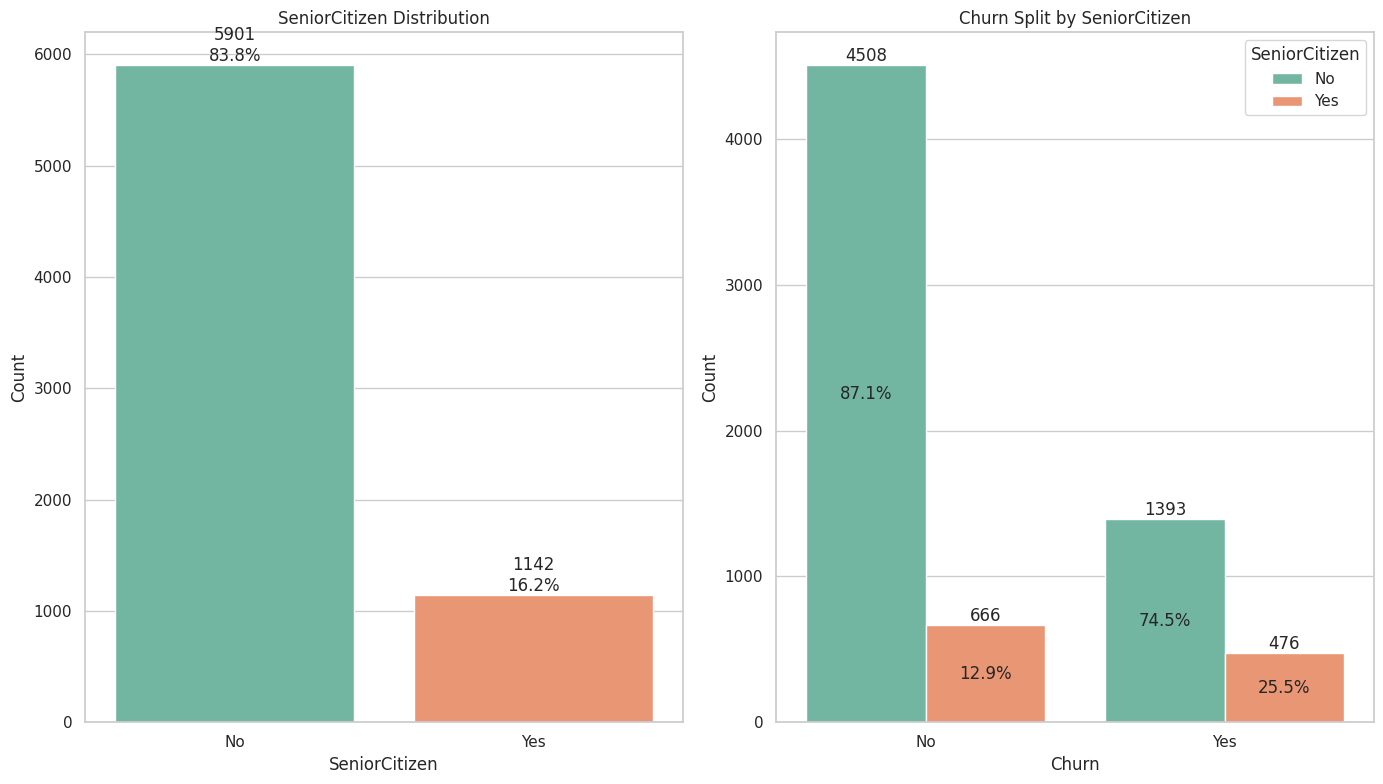

/tmp/ipykernel_55/3604604137.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='Set2', ax=ax0)
/tmp/ipykernel_55/3604604137.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby([churn_col, demo_col])


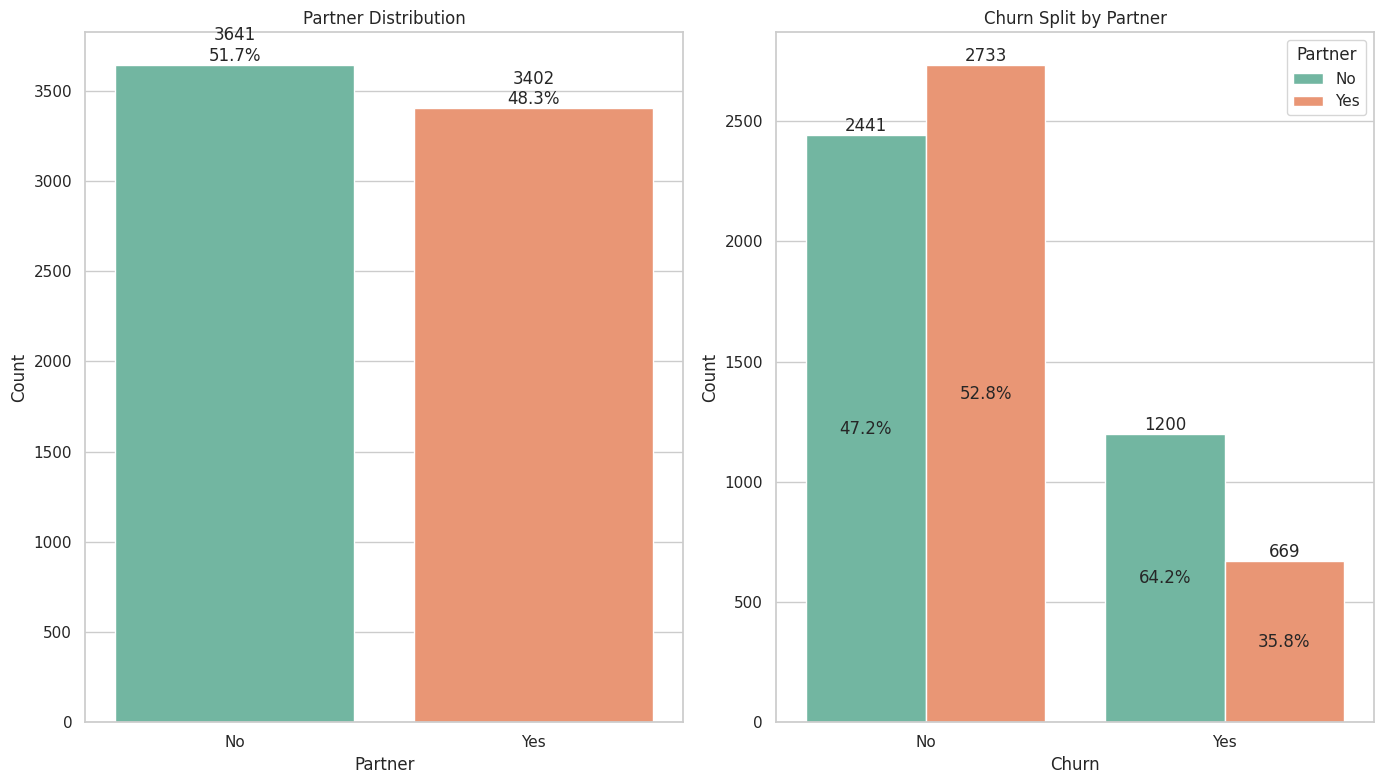

/tmp/ipykernel_55/3604604137.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='Set2', ax=ax0)
/tmp/ipykernel_55/3604604137.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby([churn_col, demo_col])


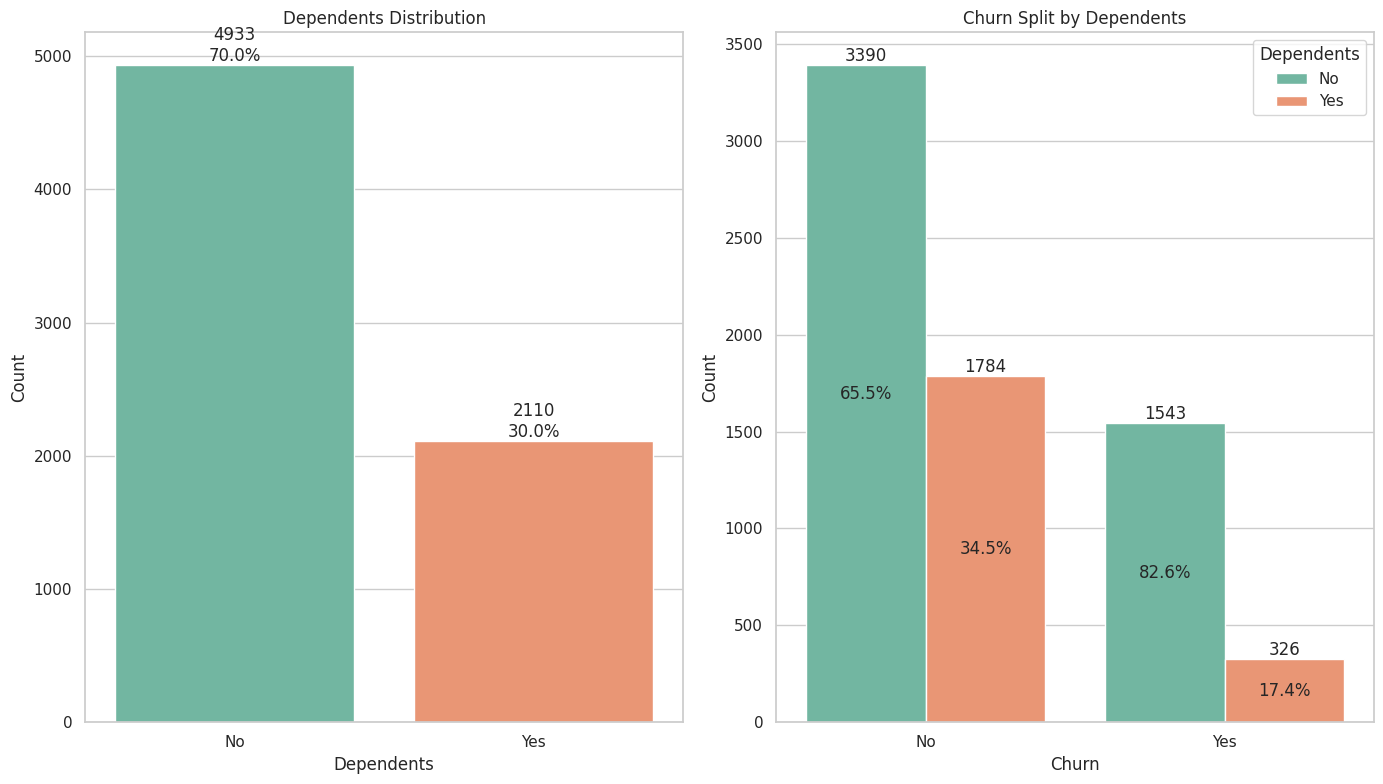

In [17]:
plot_yes_no_demo(df, 'SeniorCitizen')
plot_yes_no_demo(df, 'Partner')
plot_yes_no_demo(df, 'Dependents')

Service‑Related Churn Patterns (How does a Churner look like?)

Churners show very distinct service‑usage behaviors compared to loyal customers. The strongest patterns from the service visualizations are:
- Customers without OnlineSecurity churn significantly more, suggesting that security add‑ons act as “stickiness” features that increase retention.
- Fiber‑optic internet users churn more than DSL users, likely due to higher monthly charges and higher service expectations.
- Customers without TechSupport have much higher churn, reinforcing the idea that support‑related services reduce frustration and increase loyalty.
- StreamingTV and StreamingMovies users often have higher ARPU, and while these services don’t strongly drive churn, they correlate with customers who are more engaged but also more sensitive to price increases.
  
Overall, churners tend to have fewer value‑added services, higher‑cost internet plans, and less support coverage, creating a profile of customers who feel they pay more but receive less perceived value.


In [18]:
# Define a function to plot all service categories
def plot_service(df, col, churn_col='Churn'):
    # Detect categories automatically
    cats = list(df[col].dropna().unique())

    # If Yes/No column, enforce order
    if set(cats) == set(['Yes', 'No']):
        cats = ['No', 'Yes']

    df[col] = pd.Categorical(df[col], categories=cats, ordered=True)
    df[churn_col] = pd.Categorical(df[churn_col], categories=['No', 'Yes'], ordered=True)

    sns.set(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(15, 7))

    # Chart 1: Overall distribution
    ax0 = axes[0]
    counts = df[col].value_counts().reindex(cats).fillna(0).astype(int)
    pct = counts / counts.sum() * 100

    sns.barplot(x=counts.index, y=counts.values, palette='Pastel1', ax=ax0)
    ax0.set_title(f'{col} Distribution')
    ax0.set_xlabel(col)
    ax0.set_ylabel('Count')

    for i, v in enumerate(counts.values):
        ax0.text(i, v, f'{v}\n{pct.iloc[i]:.1f}%', ha='center', va='bottom')

    # Chart 2: Churn split
    ax1 = axes[1]
    c = (
        df.groupby([churn_col, col])
          .size()
          .reset_index(name='count')
    )

    idx = pd.MultiIndex.from_product(
        [df[churn_col].cat.categories, cats],
        names=[churn_col, col]
    )
    c = c.set_index([churn_col, col]).reindex(idx, fill_value=0).reset_index()

    c['percent_within_churn'] = (
        c.groupby(churn_col)['count']
         .transform(lambda x: x / x.sum() * 100 if x.sum() > 0 else 0)
    )

    bar = sns.barplot(data=c, x=churn_col, y='count', hue=col, palette='Pastel1', ax=ax1)
    ax1.set_title(f'Churn Split by {col}')
    ax1.set_xlabel('Churn')
    ax1.set_ylabel('Count')
    ax1.legend(title=col)

    for container in ax1.containers:
        ax1.bar_label(container, fmt='%.0f', label_type='edge')

    lookup = {(row[churn_col], row[col]): row['percent_within_churn'] for _, row in c.iterrows()}
    xticks = [t.get_text() for t in ax1.get_xticklabels()]
    hue_labels = [t.get_text() for t in ax1.legend_.get_texts()]

    for h_idx, container in enumerate(ax1.containers):
        service_val = hue_labels[h_idx]
        for r_idx, rect in enumerate(container):
            height = rect.get_height()
            if height > 0:
                churn_val = xticks[r_idx]
                pct = lookup[(churn_val, service_val)]
                ax1.text(rect.get_x() + rect.get_width()/2,
                         rect.get_y() + height/2,
                         f'{pct:.1f}%',
                         ha='center', va='center')

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_55/2689074599.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='Pastel1', ax=ax0)
/tmp/ipykernel_55/2689074599.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby([churn_col, col])


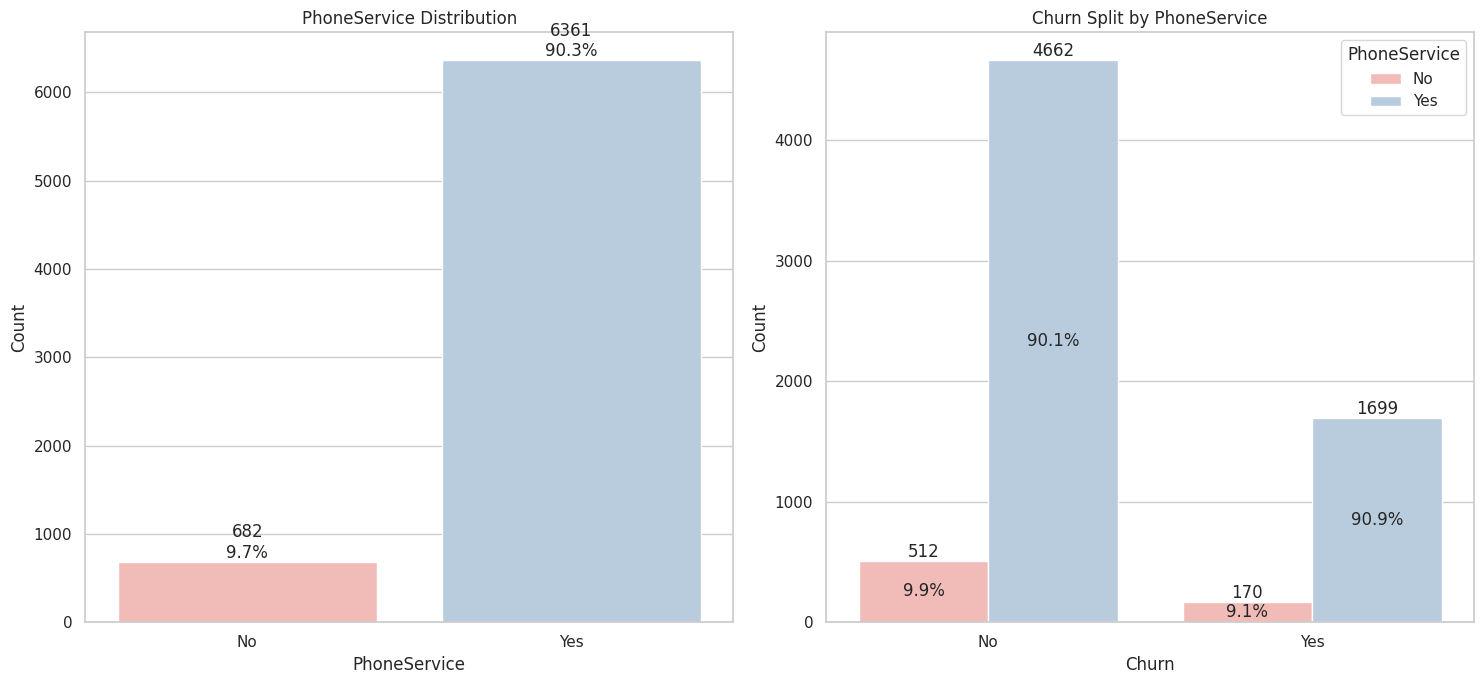

/tmp/ipykernel_55/2689074599.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='Pastel1', ax=ax0)
/tmp/ipykernel_55/2689074599.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby([churn_col, col])


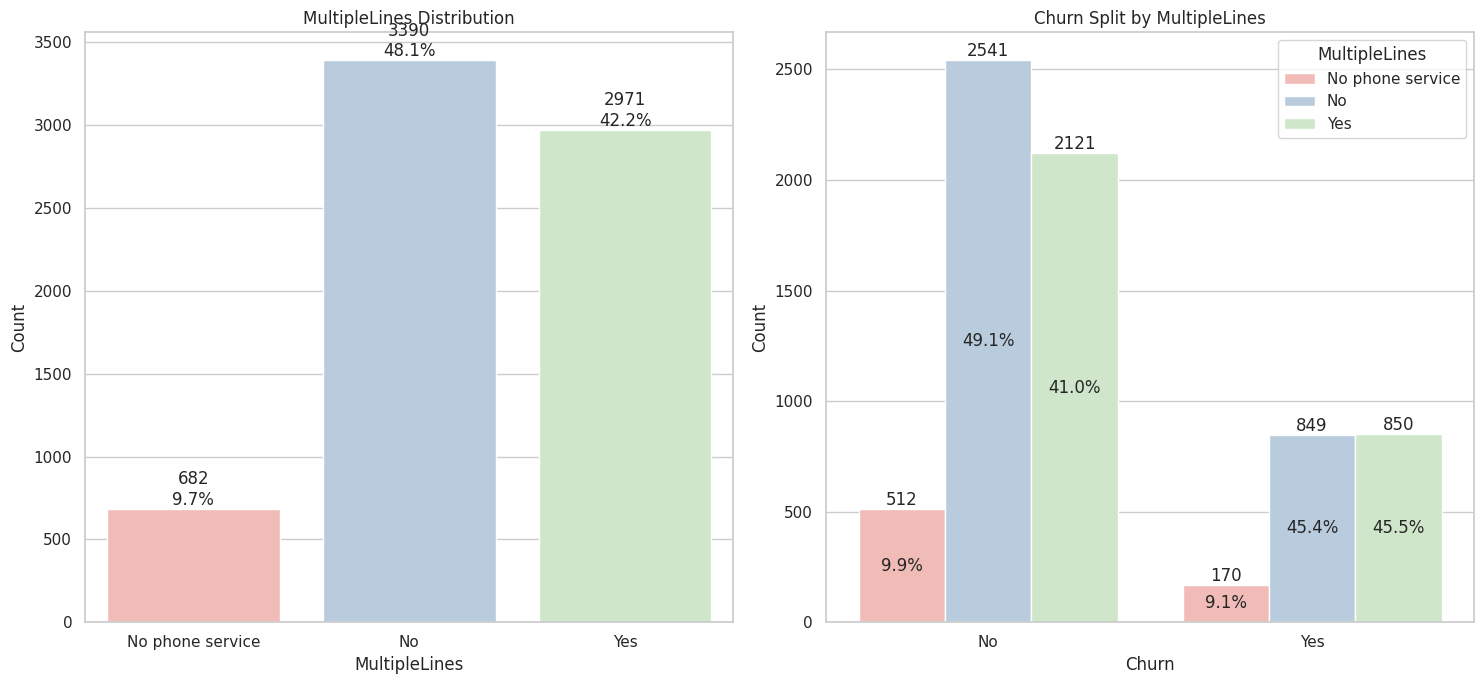

/tmp/ipykernel_55/2689074599.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='Pastel1', ax=ax0)
/tmp/ipykernel_55/2689074599.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby([churn_col, col])


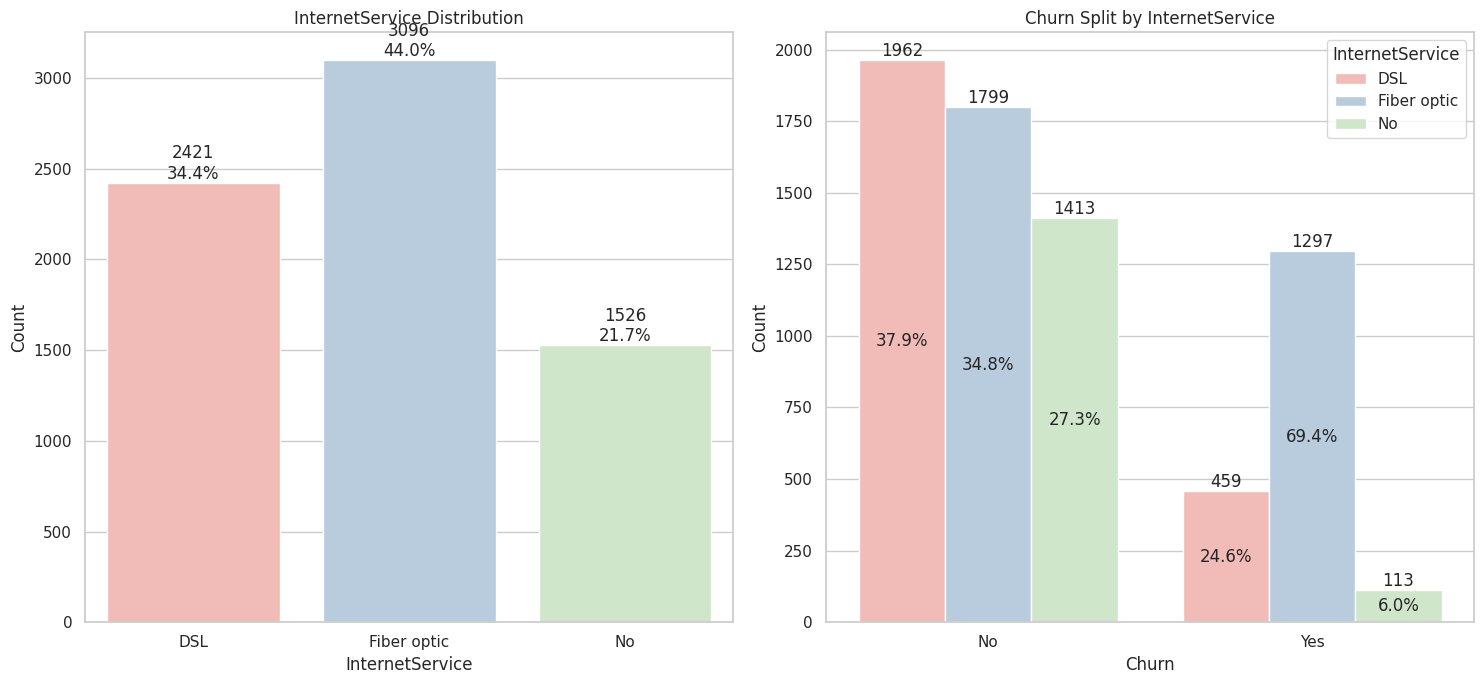

/tmp/ipykernel_55/2689074599.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='Pastel1', ax=ax0)
/tmp/ipykernel_55/2689074599.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby([churn_col, col])


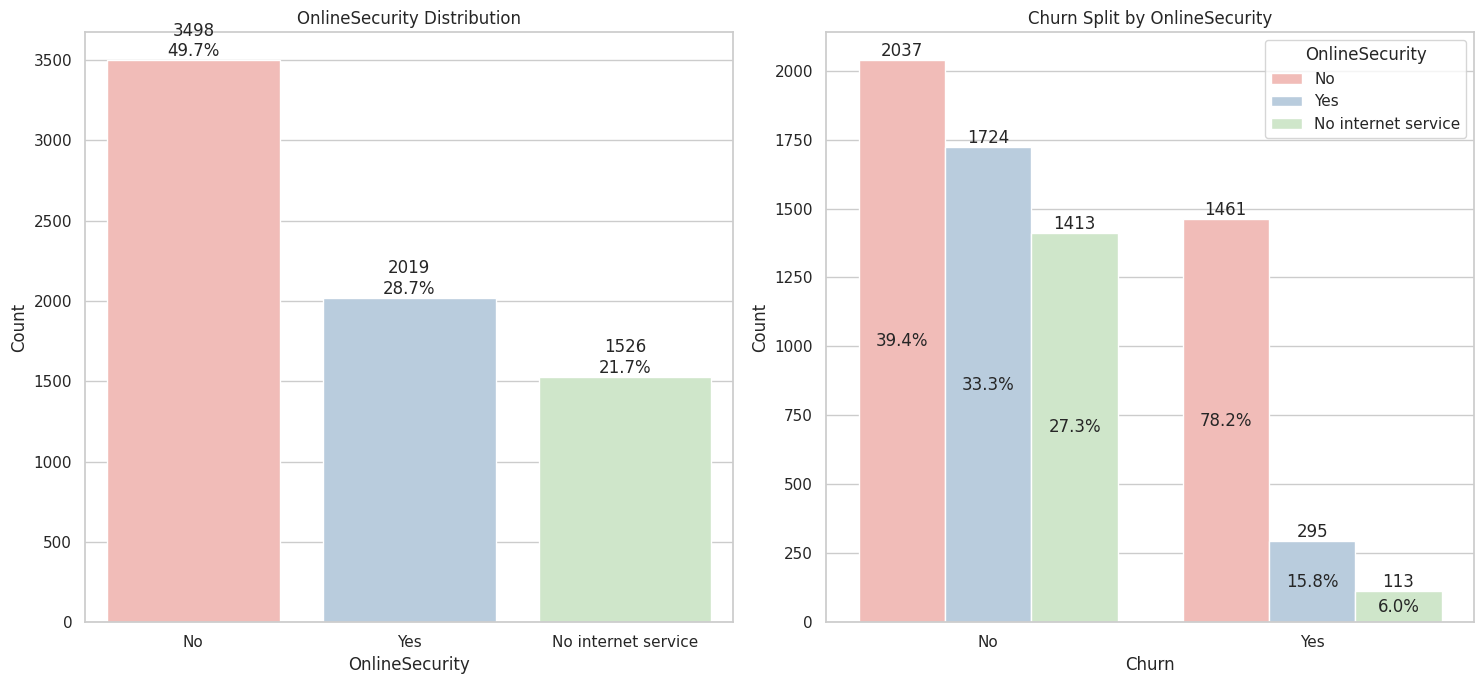

/tmp/ipykernel_55/2689074599.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='Pastel1', ax=ax0)
/tmp/ipykernel_55/2689074599.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby([churn_col, col])


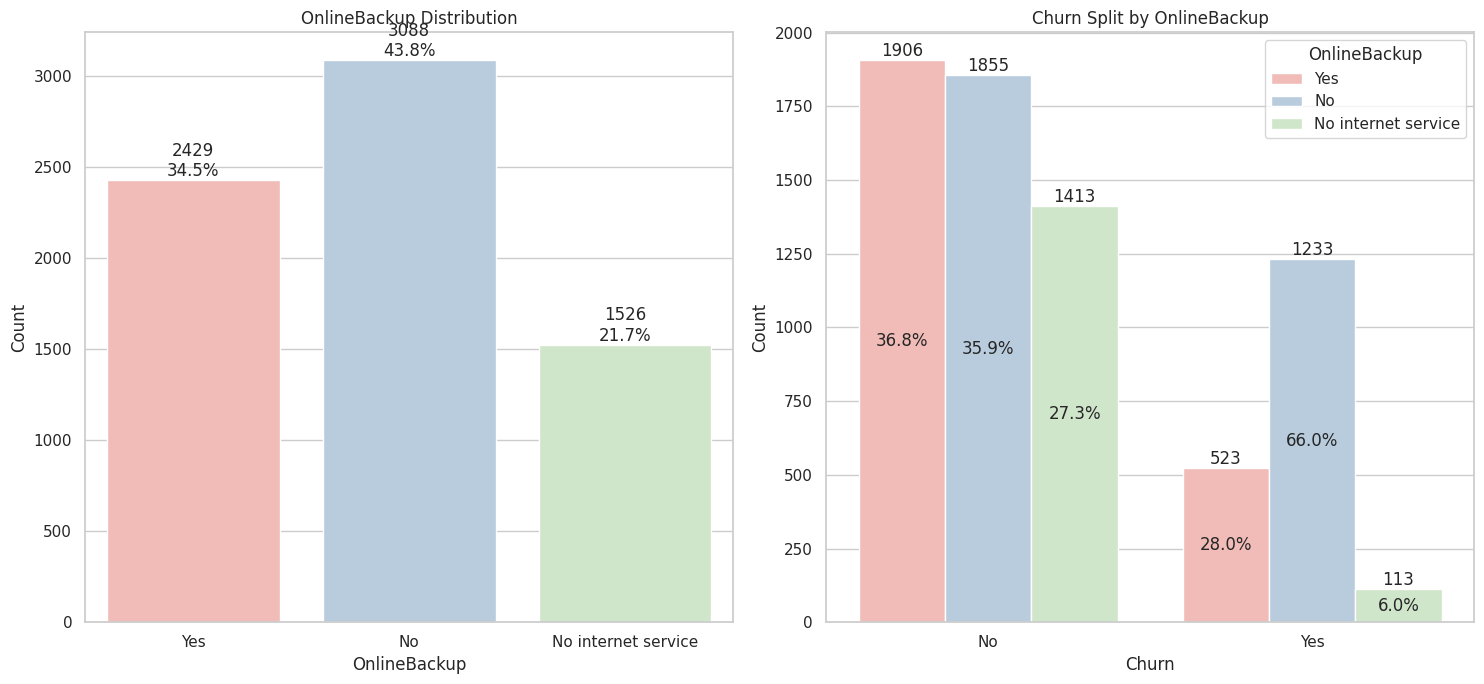

/tmp/ipykernel_55/2689074599.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='Pastel1', ax=ax0)
/tmp/ipykernel_55/2689074599.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby([churn_col, col])


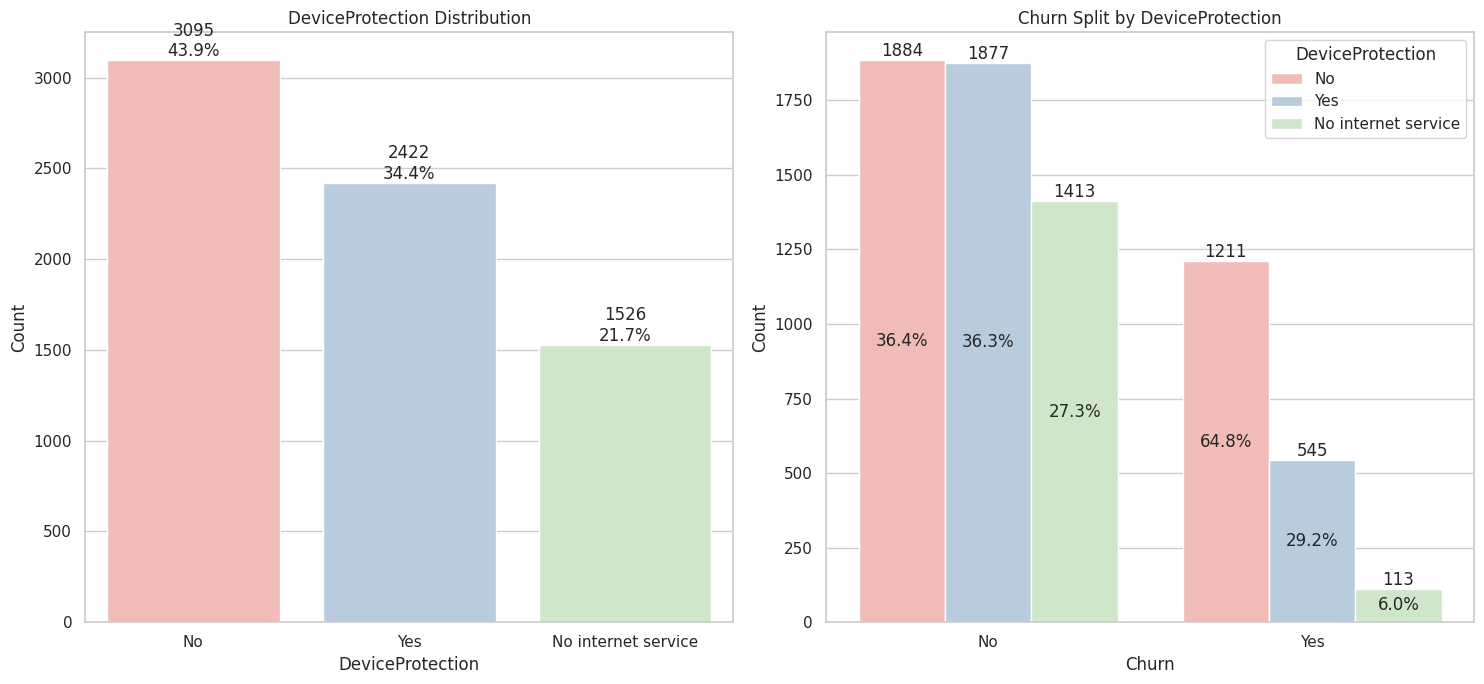

/tmp/ipykernel_55/2689074599.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='Pastel1', ax=ax0)
/tmp/ipykernel_55/2689074599.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby([churn_col, col])


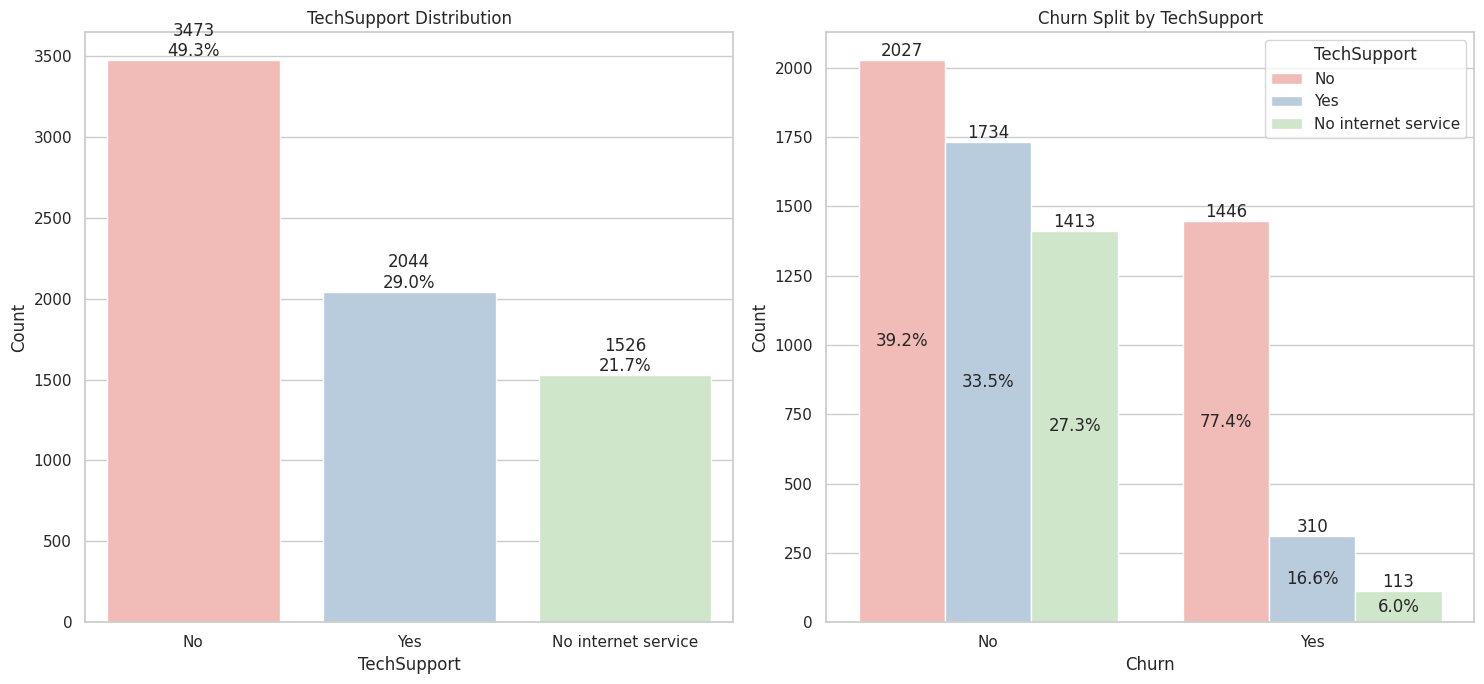

/tmp/ipykernel_55/2689074599.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='Pastel1', ax=ax0)
/tmp/ipykernel_55/2689074599.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby([churn_col, col])


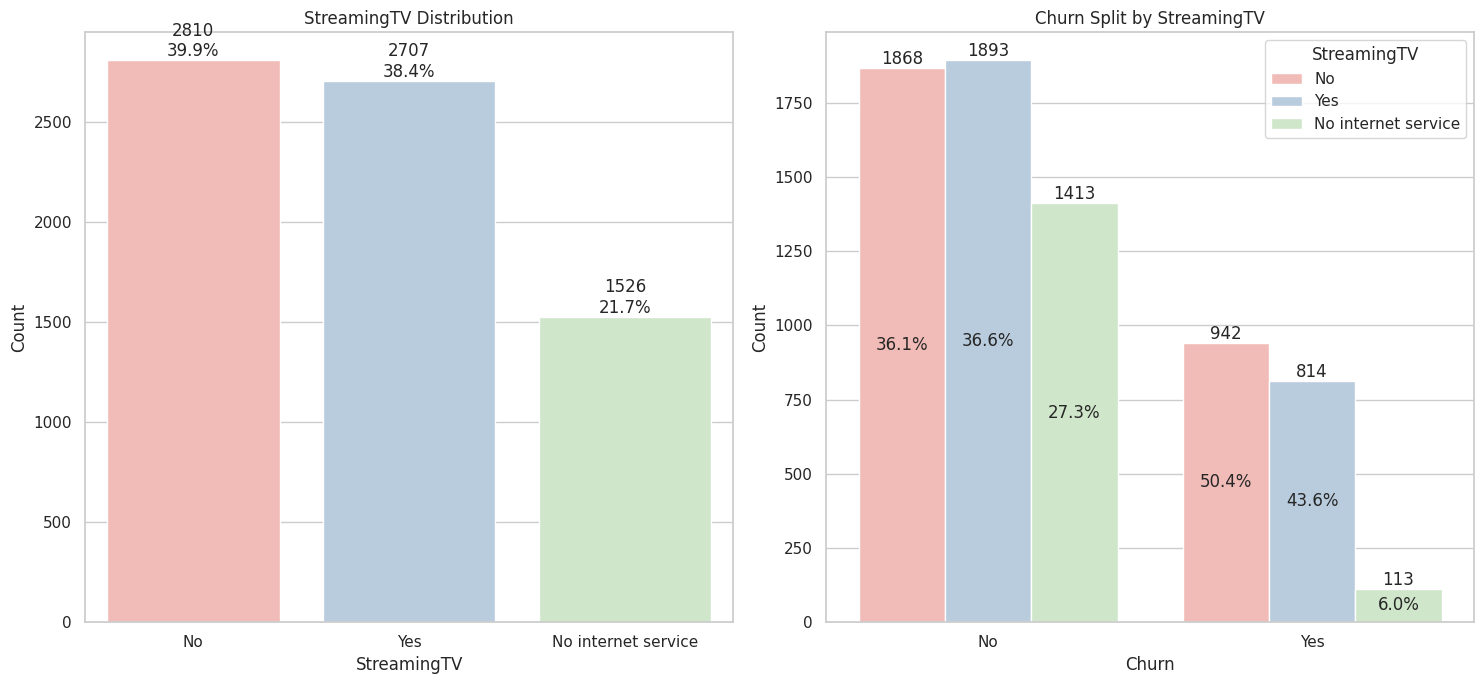

/tmp/ipykernel_55/2689074599.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='Pastel1', ax=ax0)
/tmp/ipykernel_55/2689074599.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby([churn_col, col])


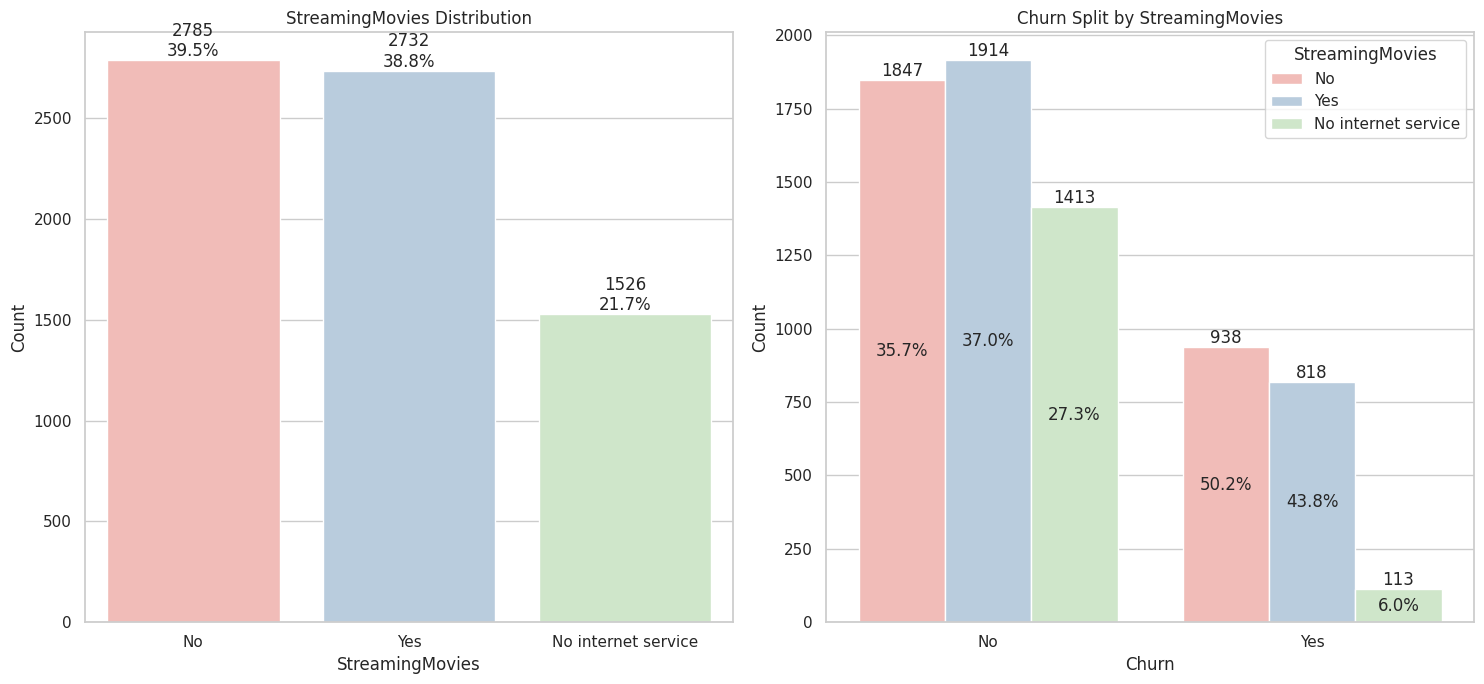

In [19]:
services = [
    'PhoneService','MultipleLines','InternetService','OnlineSecurity',
    'OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies'
]
for s in services:
    plot_service(df, s)

Churn Rate by Category 

The churn‑rate analysis highlights clear differences across customer groups:
- Month‑to‑month contracts show the highest churn, reflecting the risk associated with flexible, no‑commitment plans.
- Electronic check users churn more than any other payment method, indicating this group is less stable and potentially more price‑sensitive.
- PaperlessBilling customers show slightly higher churn, a pattern often linked to younger, more digitally oriented customers who switch providers more easily.
- Two‑year contract customers have very low churn, demonstrating the strong retention effect of long‑term commitments.
- Automatic payment methods (credit card or bank transfer) are associated with lower churn, suggesting these customers are more stable and less likely to leave.
  
Overall, contract type and payment method emerge as some of the strongest categorical predictors of churn, clearly separating high‑risk and low‑risk customer segments.



In [20]:
# Define a function to plot churn rate
def plot_churn_rate(df, col, churn_col='Churn', palette='Paired'):
    cats = list(df[col].dropna().unique())
    if col == 'Contract':
        contract_order = ['Month-to-month', 'One year', 'Two year']
        if set(cats) == set(contract_order):
            cats = contract_order

    if set(cats) == set(['Yes', 'No']):
        cats = ['No', 'Yes']

    df[col] = pd.Categorical(df[col], categories=cats, ordered=True)
    df[churn_col] = pd.Categorical(df[churn_col], categories=['No', 'Yes'], ordered=True)

    sns.set(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(15, 7))

    # Chart 1: Overall distribution
    ax0 = axes[0]
    counts = df[col].value_counts().reindex(cats).fillna(0).astype(int)
    pct = counts / counts.sum() * 100

    sns.barplot(x=counts.index, y=counts.values, palette=palette, ax=ax0)
    ax0.set_title(f'{col} Distribution')
    ax0.set_xlabel(col)
    ax0.set_ylabel('Count')

    for i, v in enumerate(counts.values):
        ax0.text(i, v, f'{v}\n{pct.iloc[i]:.1f}%', ha='center', va='bottom')

    # Chart 2: Churn rate per category
    ax1 = axes[1]
    churn_rate = (
        df.groupby(col)[churn_col]
          .apply(lambda x: (x == 'Yes').mean() * 100)
          .reindex(cats)
    )

    sns.barplot(x=churn_rate.index, y=churn_rate.values, palette=palette, ax=ax1)
    ax1.set_title(f'Churn Rate by {col}')
    ax1.set_xlabel(col)
    ax1.set_ylabel('Churn Rate (%)')

    for i, v in enumerate(churn_rate.values):
        ax1.text(i, v, f'{v:.1f}%', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_55/1060205666.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette=palette, ax=ax0)
/tmp/ipykernel_55/1060205666.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(col)[churn_col]
/tmp/ipykernel_55/1060205666.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_rate.index, y=churn_rate.values, palette=palette, ax=ax1)


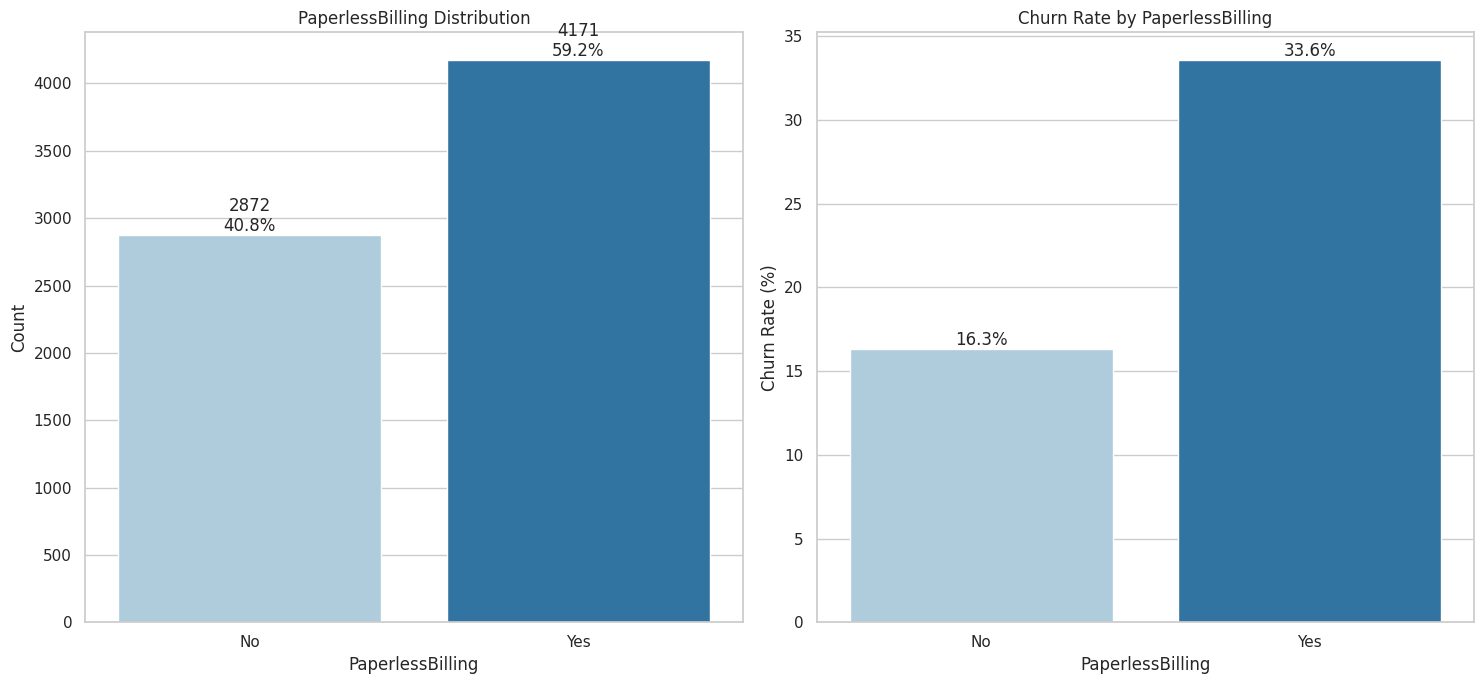

/tmp/ipykernel_55/1060205666.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette=palette, ax=ax0)
/tmp/ipykernel_55/1060205666.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(col)[churn_col]
/tmp/ipykernel_55/1060205666.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_rate.index, y=churn_rate.values, palette=palette, ax=ax1)


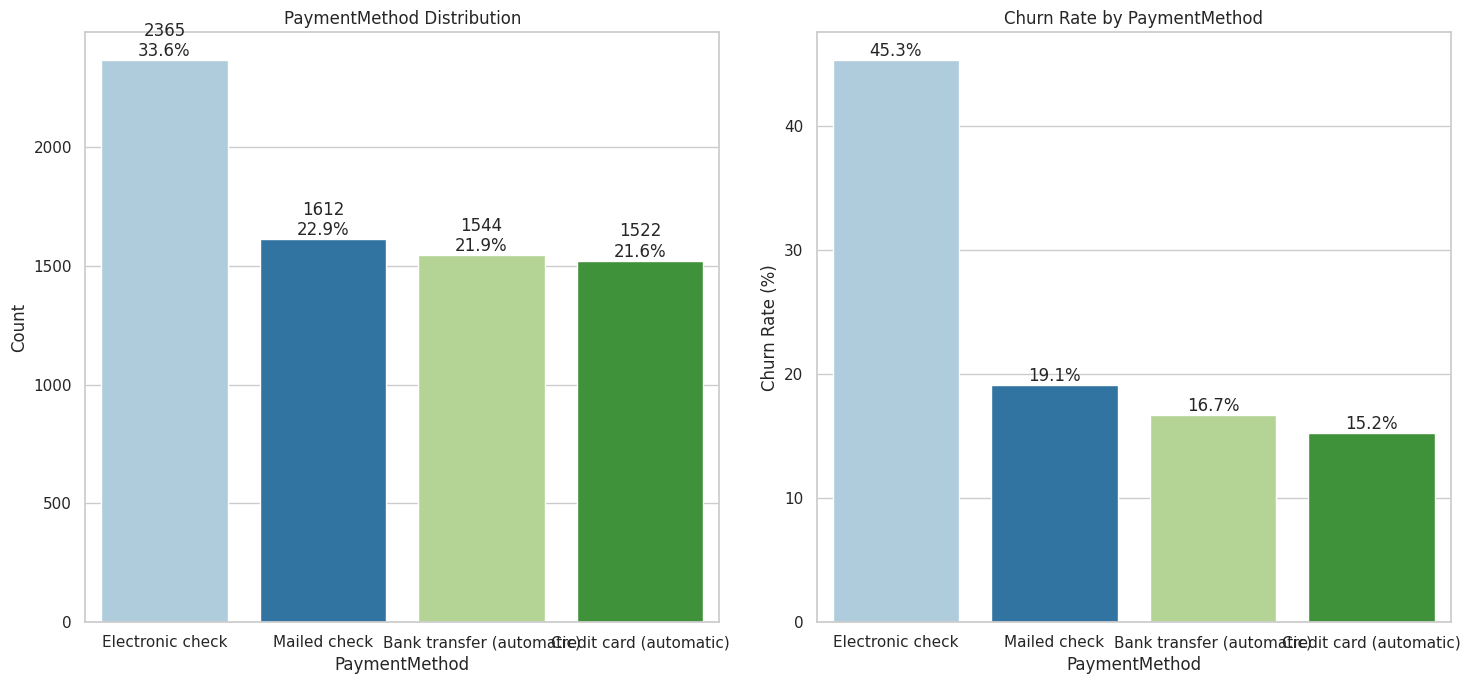

/tmp/ipykernel_55/1060205666.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette=palette, ax=ax0)
/tmp/ipykernel_55/1060205666.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(col)[churn_col]
/tmp/ipykernel_55/1060205666.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_rate.index, y=churn_rate.values, palette=palette, ax=ax1)


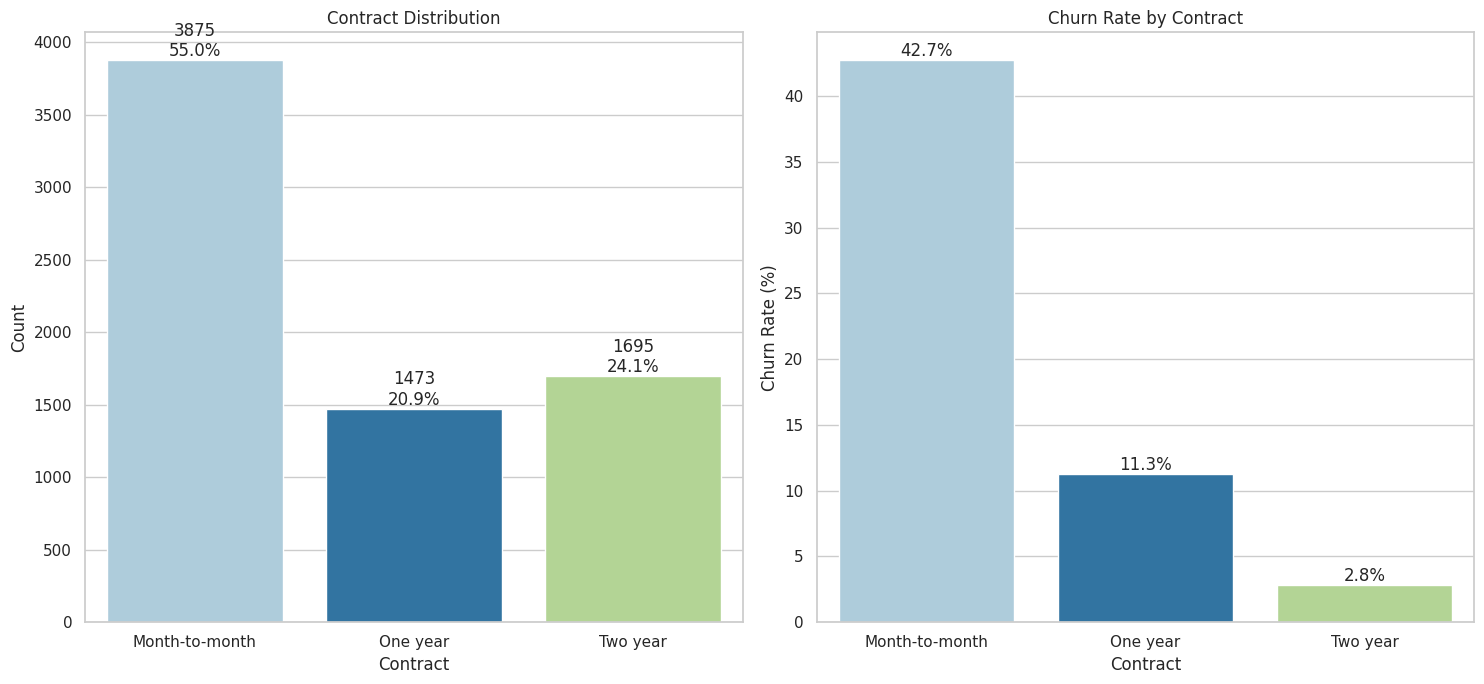

In [21]:
plot_churn_rate(df, 'PaperlessBilling')
plot_churn_rate(df, 'PaymentMethod')
plot_churn_rate(df, 'Contract')

Numeric Feature Patterns

- Customers with short tenure churn at the highest rates, especially in the first few months. Churn drops sharply after the one‑year mark, and long‑tenure customers almost never leave. This pattern reflects early‑lifecycle churn, where new customers are the most vulnerable.
- Higher monthly charges are strongly associated with higher churn. Customers paying more each month tend to be more price‑sensitive, especially when combined with month‑to‑month contracts. This reflects price pressure as a key churn driver.
- Low total charges correspond to high churn because these customers are new and have not yet built loyalty. High total charges correspond to low churn, indicating long‑term, stable customers. This reflects loyalty accumulation, where value grows over time.


In [23]:
# Define a function to plot all numberic variables
def plot_numeric_churn(df, col, churn_col='Churn', bins=10, palette='Set2'):

    sns.set(style="whitegrid")
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # Chart 1: Distribution
    ax0 = axes[0]
    sns.histplot(df[col], kde=True, color='skyblue', ax=ax0)
    ax0.set_title(f'{col} Distribution')
    ax0.set_xlabel(col)
    ax0.set_ylabel('Count')

    # Chart 2: Churn vs Non-Churn KDE
    ax1 = axes[1]
    sns.kdeplot(data=df, x=col, hue=churn_col, fill=True, common_norm=False, palette=palette, ax=ax1)
    ax1.set_title(f'{col} by Churn Status')
    ax1.set_xlabel(col)
    ax1.set_ylabel('Density')

    # Chart 3: Churn Rate by Bins
    ax2 = axes[2]
    df['bin'] = pd.qcut(df[col], q=bins, duplicates='drop')
    churn_rate = df.groupby('bin')[churn_col].apply(lambda x: (x == 'Yes').mean() * 100)

    sns.barplot(x=churn_rate.index.astype(str), y=churn_rate.values, palette=palette, ax=ax2)
    ax2.set_title(f'Churn Rate by {col} Bins')
    ax2.set_xlabel(f'{col} Range')
    ax2.set_ylabel('Churn Rate (%)')
    ax2.tick_params(axis='x', rotation=45)

    for i, v in enumerate(churn_rate.values):
        ax2.text(i, v, f'{v:.1f}%', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

    df.drop(columns=['bin'], inplace=True)

/tmp/ipykernel_55/2704636805.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_rate = df.groupby('bin')[churn_col].apply(lambda x: (x == 'Yes').mean() * 100)
/tmp/ipykernel_55/2704636805.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_rate.index.astype(str), y=churn_rate.values, palette=palette, ax=ax2)


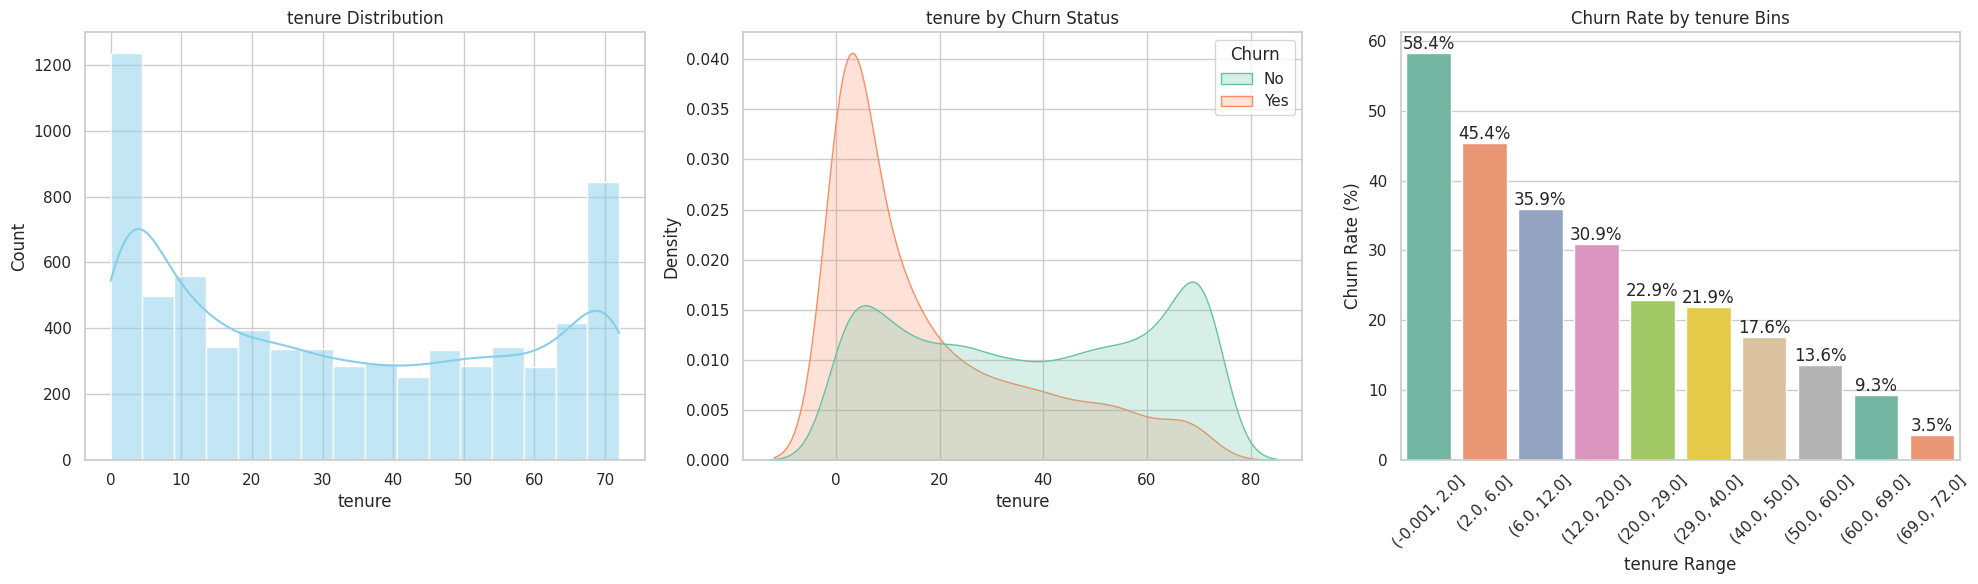

/tmp/ipykernel_55/2704636805.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_rate = df.groupby('bin')[churn_col].apply(lambda x: (x == 'Yes').mean() * 100)
/tmp/ipykernel_55/2704636805.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_rate.index.astype(str), y=churn_rate.values, palette=palette, ax=ax2)


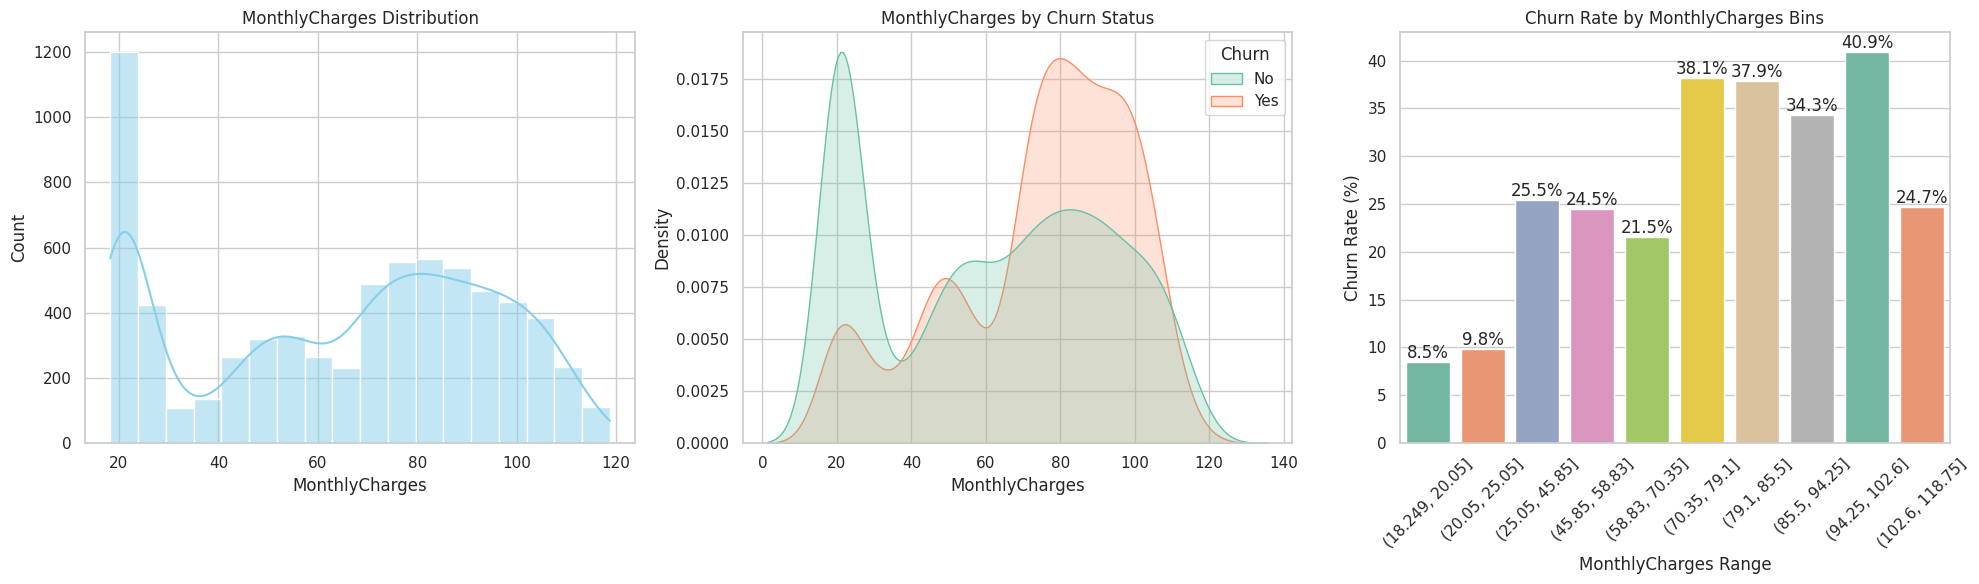

/tmp/ipykernel_55/2704636805.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_rate = df.groupby('bin')[churn_col].apply(lambda x: (x == 'Yes').mean() * 100)
/tmp/ipykernel_55/2704636805.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_rate.index.astype(str), y=churn_rate.values, palette=palette, ax=ax2)


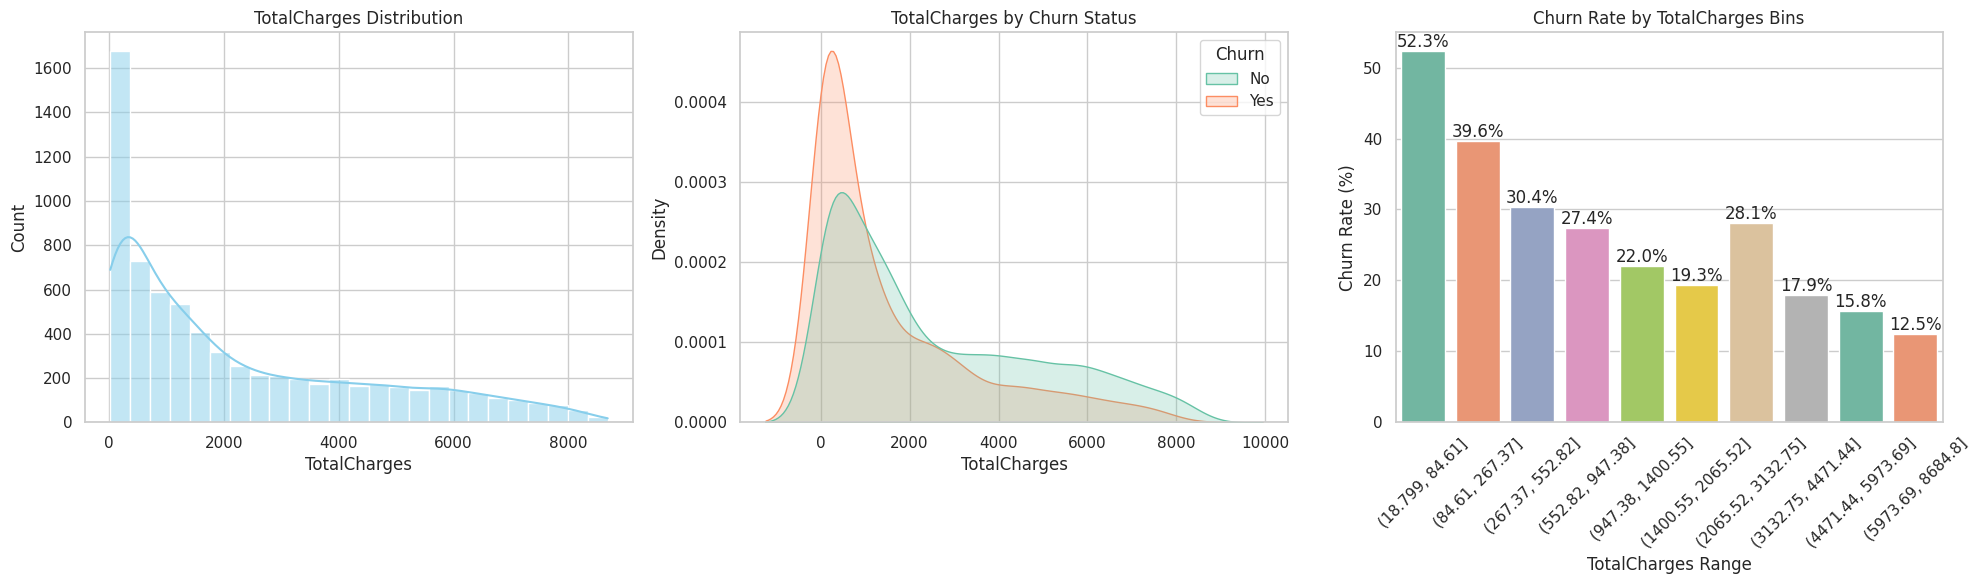

In [24]:
plot_numeric_churn(df, 'tenure')
plot_numeric_churn(df, 'MonthlyCharges')
plot_numeric_churn(df, 'TotalCharges')

**Data Preprocessing & Modelling**
- Built a clean preprocessing pipeline using StandardScaler for numeric features and OneHotEncoder for categorical features to avoid data leakage and ensure consistent transformations across all models.
- Split the data into training and test sets before applying any transformations, maintaining a leak‑free workflow.
- Trained multiple baseline models (Logistic Regression, Random Forest, XGBoost, LightGBM, SVM) to compare performance on the imbalanced churn dataset.
- Performed hyperparameter tuning using cross‑validated grid search, with XGBoost emerging as the strongest model based on ROC AUC.
- Evaluated the final tuned model using confusion matrix, classification report, ROC curve, and threshold tuning to understand precision–recall trade‑offs.
- Applied SHAP to interpret the model, identify key churn drivers, and translate model behavior into actionable business insights.


In [25]:
# Column groups
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'PaperlessBilling', 'PaymentMethod', 'Contract'
]

# Preprocessing transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

# Train/test split
X = df.drop('Churn', axis=1)
y = df['Churn'].map({'No': 0, 'Yes': 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Define 5 models
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Random Forest": RandomForestClassifier(n_estimators=300),
    "XGBoost": XGBClassifier(eval_metric='logloss'),
    "LightGBM": LGBMClassifier(),
    "SVM (RBF)": SVC(probability=True)
}

# Train and evaluate all models
results = []

for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocess', preprocessor),
        ('model', model)
    ])
    
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    probs = pipe.predict_proba(X_test)[:, 1]
    
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'F1 Score': f1_score(y_test, preds),
        'ROC AUC': roc_auc_score(y_test, probs)
    })

results_df = pd.DataFrame(results).sort_values(by='ROC AUC', ascending=False)
print("BASELINE MODEL RESULTS")
print(results_df)


# Hyperparameter tuning: Logistic Regression
log_reg_pipe = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', LogisticRegression(max_iter=2000))
])

log_reg_params = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__penalty': ['l2'],
    'model__solver': ['lbfgs']
}

log_reg_grid = GridSearchCV(
    log_reg_pipe, log_reg_params,
    cv=5, scoring='roc_auc', n_jobs=-1
)

log_reg_grid.fit(X_train, y_train)
print("\nBEST LOGISTIC REGRESSION")
print(log_reg_grid.best_params_)
print("Best CV ROC AUC:", log_reg_grid.best_score_)

# Hyperparameter tuning: XGBoost
xgb_pipe = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', XGBClassifier(eval_metric='logloss'))
])

xgb_params = {
    'model__n_estimators': [200, 400],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample': [0.7, 1.0],
    'model__colsample_bytree': [0.7, 1.0]
}

xgb_grid = GridSearchCV(
    xgb_pipe, xgb_params,
    cv=5, scoring='roc_auc', n_jobs=-1
)

xgb_grid.fit(X_train, y_train)
print("\nBEST XGBOOST")
print(xgb_grid.best_params_)
print("Best CV ROC AUC:", xgb_grid.best_score_)

[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001893 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 670
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 46
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


BASELINE MODEL RESULTS
                 Model  Accuracy  F1 Score   ROC AUC
0  Logistic Regression  0.806955  0.608069  0.841706
3             LightGBM  0.790632  0.573082  0.830919
1        Random Forest  0.781405  0.544379  0.819919
2              XGBoost  0.780696  0.560455  0.816395
4            SVM (RBF)  0.790632  0.552352  0.793283

BEST LOGISTIC REGRESSION
{'model__C': 10, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Best CV ROC AUC: 0.8458185921011904

BEST XGBOOST
{'model__colsample_bytree': 0.7, 'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 400, 'model__subsample': 0.7}
Best CV ROC AUC: 0.8500005636360648


**Evaluation**

- Hyperparameter tuning was performed on both Logistic Regression and XGBoost to identify the strongest model for churn prediction. Logistic Regression achieved a solid cross‑validated ROC AUC of 0.846, but XGBoost outperformed it with a best CV ROC AUC of 0.850, making it the top candidate for final evaluation.
- Using the tuned XGBoost model, the test‑set ROC AUC reached 0.847, confirming strong and stable discrimination between churners and non‑churners. At the default 0.5 threshold, the model captures 50% of churners, which is typical for imbalanced churn datasets. Adjusting the threshold to 0.3–0.25 significantly boosts recall to 78–82%, offering a more practical balance for real‑world retention strategies where missing a churner is more costly than contacting a non‑churner.
- Overall, the tuned XGBoost model demonstrates reliable performance, meaningful recall–precision trade‑offs, and strong generalization, making it well‑suited for churn‑reduction decision‑making.


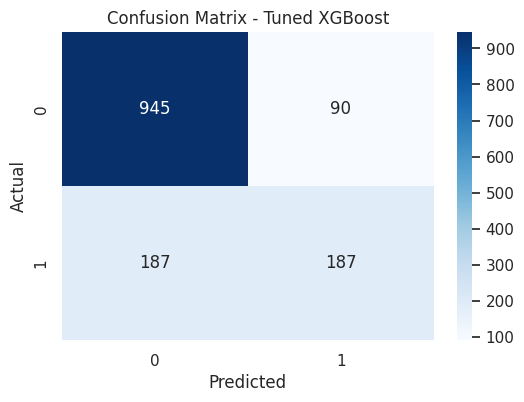

Classification Report (XGBoost)
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1035
           1       0.68      0.50      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



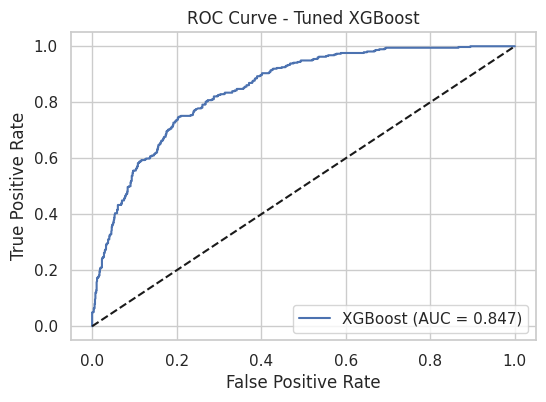

Threshold Tuning (Recall vs Precision)
Threshold 0.5: Precision=0.675, Recall=0.500
Threshold 0.4: Precision=0.598, Recall=0.644
Threshold 0.3: Precision=0.526, Recall=0.778
Threshold 0.25: Precision=0.507, Recall=0.821


In [29]:
# Best model from GridSearchCV
best_xgb = xgb_grid.best_estimator_

# Predictions
y_pred = best_xgb.predict(X_test)
y_prob = best_xgb.predict_proba(X_test)[:, 1]

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Tuned XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("Classification Report (XGBoost)")
print(classification_report(y_test, y_pred))

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"XGBoost (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned XGBoost")
plt.legend()
plt.show()

# Threshold tuning
thresholds_list = [0.5, 0.4, 0.3, 0.25]
print("Threshold Tuning (Recall vs Precision)")
for t in thresholds_list:
    preds_t = (y_prob >= t).astype(int)
    print(f"Threshold {t}: Precision={precision_score(y_test, preds_t):.3f}, Recall={recall_score(y_test, preds_t):.3f}")

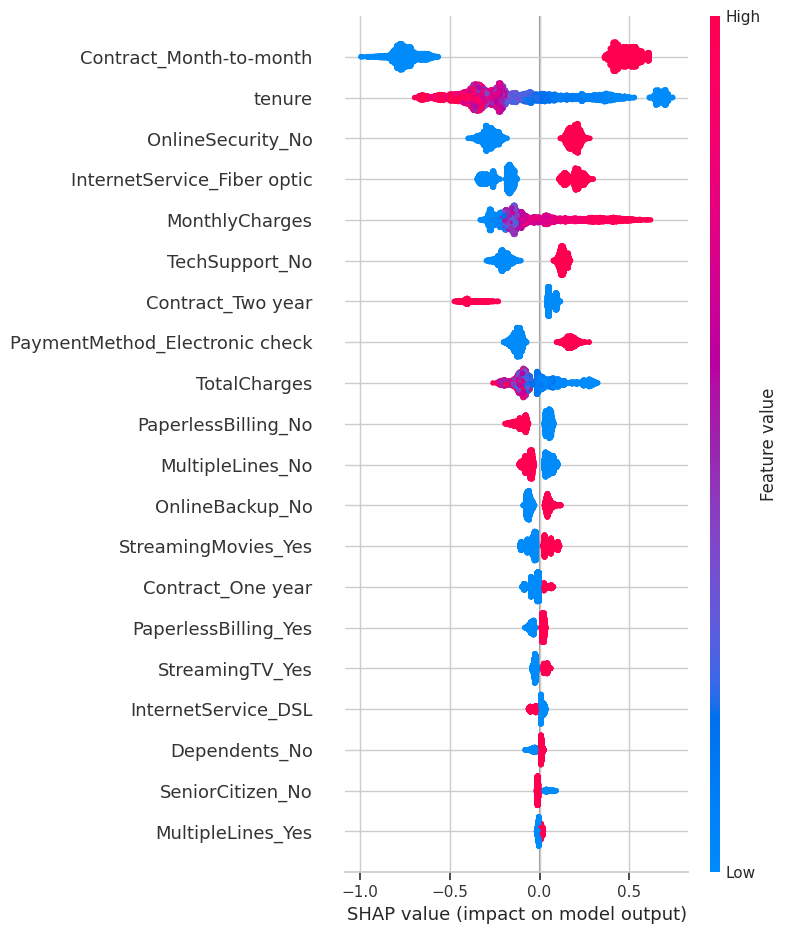

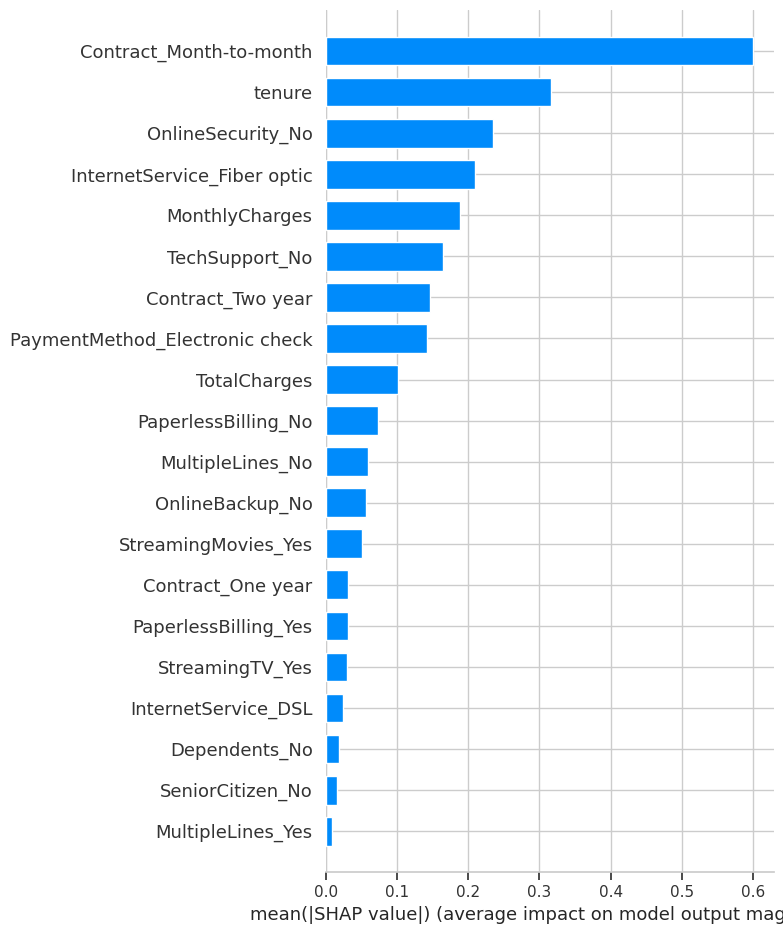

In [30]:
best_xgb = xgb_grid.best_estimator_
best_xgb.fit(X_train, y_train)

# Get the preprocessed feature matrix
X_train_transformed = best_xgb.named_steps['preprocess'].transform(X_train)

# Get feature names after one-hot encoding
ohe = best_xgb.named_steps['preprocess'].named_transformers_['cat']
ohe_features = ohe.get_feature_names_out(categorical_cols)

num_features = numeric_cols
all_features = np.concatenate([num_features, ohe_features])

# Run SHAP
import shap
shap.initjs()

# Use TreeExplainer for XGBoost
explainer = shap.TreeExplainer(best_xgb.named_steps['model'])
shap_values = explainer.shap_values(X_train_transformed)

# Global feature importance
shap.summary_plot(shap_values, X_train_transformed, feature_names=all_features)

# Bar plot
shap.summary_plot(shap_values, X_train_transformed, feature_names=all_features, plot_type="bar")

**SHAP**

- Tenure — customers with short tenure churn more
   
   Short‑tenure customers (blue dots) appear on the right, meaning they push churn up. Long‑tenure customers (red dots) appear on the left, meaning they push churn down.
   - New customers are unstable and more likely to leave.
   - Long‑term customers are “sticky” and loyal.


- MonthlyCharges — high charges increase churn

   High charges (red) appear on the right, pushing churn up. Low charges (blue) appear on the left, pushing churn down.
   - High‑spend customers feel price pressure.
   - Low‑spend customers are more satisfied with value.

- Contract type — Month‑to‑month drives churn

   For the one‑hot encoded feature Contract_Month-to-month:
   - Red dots (value = 1 → customer is month‑to‑month) appear on the right → increases churn.
   - Blue dots (value = 0 → customer is not month‑to‑month) appear on the left → decreases churn.
   Longer contracts (One year, Two year) show the opposite pattern:
   - Red dots for Contract_Two year appear on the left → reduces churn.

- OnlineSecurity — lack of security increases churn

   For OnlineSecurity_No:
   - Red dots (customer has no security) appear on the right → increases churn.
   - Blue dots (customer has security) appear on the left → reduces churn.

- TechSupport — lack of support increases churn

   The pattern mirrors OnlineSecurity:
   - No tech support → red on the right → increases churn.
   - Has tech support → blue on the left → reduces churn.

- InternetService — Fiber optic increases churn

   For InternetService_Fiber optic:
   - Red dots appear on the right → fiber customers churn more.
   - Blue dots (DSL or No internet) appear on the left → churn less.
 
- PaymentMethod — Electronic check increases churn

   For PaymentMethod_Electronic check:
   - Red dots on the right → electronic check users churn more.
   - Blue dots on the left → other payment methods churn less.

- PaperlessBilling — paperless customers churn more

   Paperless billing often correlates with:
   - younger customers
   - month‑to‑month contracts
   - electronic check payments

- TotalCharges — low total charges increase churn

   Low total charges (blue) appear on the right, meaning:
   - customers who haven’t spent much yet (new customers) churn more.

- Streaming services — weak but directional

    Features like StreamingTV and StreamingMovies have small but consistent patterns:
    - Having streaming services (red) slightly reduces churn.
    - Not having them (blue) slightly increases churn.

Overall, 
- New, high‑charge, month‑to‑month customers with no security/support churn the most.
- Long‑tenure, low‑charge, contract‑bound customers with bundled services churn the least.

**Business Insights from the Churn Model**

The tuned XGBoost model (ROC AUC ≈ 0.85) reveals clear, consistent churn drivers. SHAP analysis shows how each factor pushes customers toward leaving or staying, allowing us to translate model behaviour into business meaning.

- Tenure is the strongest churn predictor

   Customers with short tenure show the highest churn risk. This indicates a fragile early relationship where expectations may not be met.

   Business implication: the first 3–6 months are critical. Customers who don’t settle in quickly are likely to leave.

   Recommendation, introduce an onboarding program:
   - welcome calls
   - setup assistance
   - early check‑ins
   - usage tips

- High MonthlyCharges increase churn

   High‑spend customers are more likely to churn, especially when combined with fiber internet or lack of support services.
 
   Business implication: price sensitivity is a major churn driver.
 
   Recommendation, offer targeted retention incentives:
   - loyalty discounts
   - bundle pricing
   - personalized offers for high‑charge customer


- Month‑to‑month contracts drive churn

   SHAP shows that being on a month‑to‑month contract strongly pushes churn upward, while one‑year and two‑year contracts reduce churn.

   Business implication: contract structure is one of the most powerful levers for retention.

   Recommendation, promote contract upgrades:
   - small discounts for switching to annual plans
   - free add‑ons for committing to longer terms
   - targeted campaigns for high‑risk month‑to‑month customers
  
- Lack of OnlineSecurity and TechSupport increases churn

   Customers without these add‑on services show significantly higher churn risk.

   Business implication: support and security services act as “stickiness” features.

   Recommendation, upsell value‑add services:
   - bundle OnlineSecurity with internet plans
   - offer discounted TechSupport for new customers
   - create “protection packages” for at‑risk segments

- Fiber optic customers churn more

   Fiber customers often pay higher charges and have higher expectations. SHAP shows they are more likely to churn than DSL customers.

   Business implication: fiber customers may be more sensitive to service quality or price.

   Recommendation, improve fiber customer experience:
   - proactive service quality monitoring
   - premium support for fiber users
   - targeted satisfaction surveys
  
- Electronic check payment method is a churn signal

   Customers paying via electronic check show higher churn risk than those using credit card or bank transfer.

   Business implication: payment method is a behavioural indicator of churn.

   Recommendation, encourage more stable payment methods:
   - incentives for switching to credit card or direct debit
   - simplified payment method change process




**Strategic Recommendations for the Business**

- Targeted retention campaigns

   Use the model to identify high‑risk customers and intervene early:
   - short‑tenure customers
   - high‑charge customers
   - month‑to‑month contract holders
   - customers without support/security services
  
- Personalized offers

   Tailor offers based on churn drivers:
   - discounts for high‑charge customers
   - contract upgrade incentives
   - bundled security/support services
  
- Proactive customer engagement

   Focus on customers in their first 3 months:
   - onboarding calls
   - satisfaction check‑ins
   - troubleshooting assistance
  
- Integrate the model into CRM

   Deploy the model to score customers weekly or monthly:
   - flag high‑risk accounts
   - trigger automated retention workflows
   - track churn risk over time
